In [2]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
## 데이터셋, 데이터로더 관련 모듈
from torch.nn.utils.rnn import pad_sequence
## 데이터 길이 맞추기

## 토커나이저, 단어사전 관련 모듈
from torchtext.data.utils import get_tokenizer              ## 토커나이저 인스턴스 추출
from torchtext.vocab import build_vocab_from_iterator       ## 데이터셋에서 단어사전 생성 함수
from nltk.corpus import stopwords                           ## 불용어 데이터셋
import nltk
from nltk.tokenize import word_tokenize

c:\Users\kdt\anaconda3\envs\NLP\lib\site-packages\torchtext\data\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
c:\Users\kdt\anaconda3\envs\NLP\lib\site-packages\torchtext\vocab\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
c:\Users\kdt\anaconda3\envs\NLP\lib\site-packages\torchtext\utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATU

In [3]:
dataDF = pd.read_csv('./dataDF.csv', index_col=0, encoding='utf-8')

In [4]:
texts = dataDF['Dialogue'].tolist()
labels = dataDF['age'].tolist()
len(texts), len(labels)

(16722, 16722)

In [5]:
### ===> 모듈 로딩
from konlpy.tag import Okt
from torchtext.vocab import build_vocab_from_iterator
import string
### ===> 토큰관련 특별 문자
UNK = '<UNK>'
PAD = '<PAD>'
### 토큰화 인스턴스 생성
tokenizer = Okt()
### ===> 토큰 제너레이터 함수 : 데이터 추출하여 토큰화 


In [6]:
PUNC = string.punctuation
STOPWORDS = [
    # 조사 / 불필요 접속어
    '은', '는', '이', '가', '을', '를', '에', '에서', '으로', '의', '도', '만', '까지', '부터',
    '과', '와', '하고', '보다', '보다도',

    # 보조동사 및 흔한 표현
    '있다', '없다', '되다', '해요', '해', '했어요', '했네', '했지', '하지', '그랬지', '그래요', '같아요',
    
    # 대명사 / 불분명 주어
    '그', '저', '이', '것', '거', '자기', '우리', '너', '나', '누구', '사람', '다', '뭐',

    # 웹체 / 감탄 / 의미 낮은 부사
    '정말', '그냥', '좀', '매우', '많이', '아주', '거의', '조금', '계속', '항상', '진짜',
    
    # 대화 문법 전환
    '그래서', '그런데', '그러니까', '하지만', '그리고', '그러면',

    # 의성어 / 감탄사 / 불필요한 감정어
    '티티', '아가씨', '수고했다', '감사합니다', '고맙다', '고마워서', '선물', '미신이야',

    # 웹 말투
    'ㅋㅋ', 'ㅎㅎ', 'ㅠㅠ', '...', '!!', '??'
]
UNK, PAD  = '<UNK>',  '<PAD>'

In [7]:
# def yield_tokens(data):
#     for line in data:
#         line = ''.join([x for x in line if x not in PUNC])
#         yield word_tokenize(line.lower())


In [8]:
# VOCAB = build_vocab_from_iterator(yield_tokens(texts), specials=[UNK, PAD])
# VOCAB.set_default_index(VOCAB[UNK])
# len(VOCAB)

In [9]:
tokenizer = Okt()
tokens = [tokenizer.morphs(i) for i in texts if i not in PUNC]

In [10]:
len(tokens)

16693

In [11]:
len(texts), len(labels)

(16722, 16722)

In [12]:
from gensim.models import Word2Vec


word2vec = Word2Vec(
    sentences=tokens,
    vector_size=128,
    window=5,
    min_count=1,
    sg=1,
    epochs=10,
    max_final_vocab=10000
)

# 2. UNK 토큰 추가
unk_vector = np.random.normal(scale=0.6, size=(word2vec.vector_size,))
word2vec.wv.add_vector(UNK, unk_vector)

# 3. 단어 인덱스 매핑
word2index = word2vec.wv.key_to_index
unk_index = word2index[UNK]

# 4. 임베딩 weight → PyTorch 임베딩 레이어
embedding_weights = torch.FloatTensor(word2vec.wv.vectors)
embedding_layer = torch.nn.Embedding.from_pretrained(embedding_weights, freeze=False)

c:\Users\kdt\anaconda3\envs\NLP\lib\site-packages\gensim\models\keyedvectors.py:551: UserWarning: Adding single vectors to a KeyedVectors which grows by one each time can be costly. Consider adding in batches or preallocating to the required size.
  warnings.warn(


In [13]:
## 배치크기만큼 데이터 로딩 시 위치 지정 위한 설정 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [14]:
# 레이블 매핑 딕셔너리 정의
label_map = {80: 0, 90: 1, 00: 2, 10: 3}
# 예상치 못한 레이블이 들어올 경우 처리할 기본값 (예: 0 또는 특정 UNK 레이블 인덱스)
default_label_index = 0 # 또는 -1 등으로 설정 후 후처리

In [15]:
len(texts), len(labels)

(16722, 16722)

In [16]:
def label_pipeline(label_str):
    """주어진 문자열 레이블('80', '90', '00', '10')을 정수 인덱스(0, 1, 2, 3)로 변환"""
    index = label_map.get(label_str, default_label_index)
    if label_str not in label_map:
         print(f"Warning: 예상치 못한 레이블 '{label_str}' 발견. 기본값 {default_label_index}로 처리합니다.")
    return index

def text_pipeline(text):
    tokens = tokenizer.morphs(text) # Okt 토크나이저 사용
    # word2index 딕셔너리를 사용하여 인덱스로 변환, 없으면 unk_index 사용
    return [word2index.get(token, unk_index) for token in tokens]

In [17]:
## ----------------------------------------------------------------------
## 함수기능 : 배치크기 만큼 데이터셋 로딩해서 토큰 + 텐서화 진행 후 반환
## ----------------------------------------------------------------------
def collate_batch(batch):
    ## 라벨, 뉴스, 뉴스기사 시작 위치값 저장 변수
    label_list, diag_list, offsets = [], [], [0]

    ## 1개씩 라벨과 뉴스 기사 추출
    for label, news in batch:
        if not isinstance(news, str):
             print(f"❌ 잘못된 뉴스 타입: {type(news)} - 값: {news}")
        ## 라벨 인코딩 후 추가 : 1 ~ 4 => 0 ~ 3
        label_list.append(label_pipeline(label))

        ## 뉴스 기사 인코딩 후 추가 
        processed_news = torch.tensor(text_pipeline(news), dtype=torch.int64)
        diag_list.append(processed_news)

        ## 다음 뉴스를 읽기 위한 위치값 정보
        offsets.append(processed_news.size(0))
        #print(f'news 토큰 수 => {processed_news.size(0)}개')

    ## 배치 크기 만큼의 라벨 리스트 => 텐서화
    label_list = torch.tensor(label_list, dtype=torch.int64)

    ## 배치 크기 만큼의 길이 위치값 => 텐서화 
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    ## 배치 크기 만큼의 뉴스 기사 리스트 => 텐서화 
    diag_list = torch.cat(diag_list)

    return label_list.to(DEVICE), diag_list.to(DEVICE), offsets.to(DEVICE)


In [18]:
class customDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return  self.labels[idx], self.sequences[idx]


In [19]:
len(texts), len(labels)

(16722, 16722)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# from sklearn.preprocessing import LabelEncoder

# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_val = le.transform(y_val)
# y_test = le.transform(y_test)

train_dataset = customDataset(X_train, y_train)
val_dataset = customDataset(X_val, y_val)
test_dataset = customDataset(X_test, y_test)

# train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=100, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [21]:
len(train_dataset)

13377

In [22]:
## => DataLoader 생성
### ===> 학습용, 검증용, 테스트용 DataSet 준비 
BATCH_SIZE = 100

### 학습용, 검증용, 테스트용 Dataset, DataLoader 준비
trainDL = DataLoader( train_dataset, 
                      batch_size=BATCH_SIZE, 
                      shuffle=True, 
                      collate_fn=collate_batch )

validDL  = DataLoader( val_dataset, 
                       batch_size=BATCH_SIZE,  
                       shuffle=True,  
                       collate_fn=collate_batch )
                      
testDL  = DataLoader( test_dataset, 
                      batch_size=BATCH_SIZE,  
                      shuffle=True,  
                      collate_fn=collate_batch )

In [23]:
len(texts), len(labels)

(16722, 16722)

In [24]:
for idx, (label, text, offsets) in enumerate(trainDL):
    print(idx, label.shape, text.shape, offsets.shape)
    break

0 torch.Size([100]) torch.Size([895]) torch.Size([100])


In [25]:
### ===> 모듈로딩
import torch.nn as nn
import torch.optim as optim 
from torch.optim.lr_scheduler import StepLR

In [26]:
## -------------------------------------------------------------------------
## 클래스이름 : TextModel
## 부모클래스 : Module
## 매개변수둘 : 단어사전 갯수, 임베딩 수, 2진분류
## -------------------------------------------------------------------------
# class TextDnnEmbModel(nn.Module):
#     def __init__(self, vocab_size, embedding_dim=256, hidden_dim=4):
#         super().__init__()
#         self.embedding_layer = nn.Embedding(vocab_size, embedding_dim)
        
#         self.classifier = nn.Sequential(
#             nn.Linear(embedding_dim, hidden_dim),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(hidden_dim, hidden_dim // 2),
#             nn.ReLU(),
#             nn.Linear(hidden_dim // 2, 4)  # 4개 클래스
#         )

#     def forward(self, text, offsets):
#         embedded = self.embedding_layer(text, offsets)  # (batch_size, seq_len, emb_dim)
#         # pooled = embedded.mean(dim=1)          # (batch_size, emb_dim)
#         return self.classifier(embedded)


    

In [27]:
# ## -------------------------------------------------------------------------
# ## 클래스이름 : TextModel
# ## 부모클래스 : Module
# ## 매개변수둘 : 단어사전 갯수, 임베딩 수, 분류_클래스 갯수 
# ## -------------------------------------------------------------------------
# class TextModel(nn.Module):
#     ## 모델 층 정의 메서드 --------------------------------------
#     def __init__(self, vocab_size, embed_dim, num_class):
#         super().__init__()
#         ## 고차원 ==> 저차원 
#         self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)
#         ## 다중 분류 
#         self.fc = nn.Linear(embed_dim, num_class)
#         ## 초기 가중치 => self.메서드이름() : 같은 클래스에 존재하는 메서드 호출
#         self.init_weights()

#     ## 가중치 초기화 기능의 메서드 ---------------------------
#     def init_weights(self):
#         initrange = 0.5
#         self.embedding.weight.data.uniform_(-initrange, initrange)
#         self.fc.weight.data.uniform_(-initrange, initrange)
#         self.fc.bias.data.zero_()

#     ## 전방향 학습 메서드 -------------------------------------------
#     def forward(self, text, offsets):
#         ## 배치크기만큼 학습 데이터 
#         embedded = self.embedding(text, offsets)
#         # 다중 분류로 손실함수에서 softmax() 처리 
#         return self.fc(embedded)     


In [ ]:
## 클래스이름 : TextModelComplex
## 부모클래스 : Module
## 매개변수   : 단어사전 갯수(vocab_size), 임베딩 차원(embed_dim),
##              중간 은닉층 차원(hidden_dim), 분류 클래스 갯수(num_class),
##              드롭아웃 확률(dropout_p)
## -------------------------------------------------------------------------
class TextModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_class, dropout_p=0.7):
        super().__init__() 
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(hidden_dim, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc1.weight.data.uniform_(-initrange, initrange)
        self.fc1.bias.data.zero_()
        self.fc2.weight.data.uniform_(-initrange, initrange)
        self.fc2.bias.data.zero_()

    ## 순전파 학습 메서드 -------------------------------------------
    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        hidden = self.fc1(embedded)
        hidden = self.relu(hidden)
        hidden = self.dropout(hidden)
        output = self.fc2(hidden)
        return output

In [62]:
# ## 클래스이름 : TextModelLSTM
# ## 부모클래스 : Module
# ## 매개변수   : 단어사전 갯수(vocab_size), 임베딩 차원(embed_dim),
# ##              LSTM 은닉층 차원(lstm_hidden_dim), 분류 클래스 갯수(num_class),
# ##              LSTM 레이어 수(lstm_layers), 양방향 여부(bidirectional),
# ##              FC 은닉층 차원(fc_hidden_dim, 옵션), 드롭아웃 확률(dropout_p)
# ## -------------------------------------------------------------------------
# class TextModelLSTM(nn.Module):
#     ## 모델 층 정의 메서드 --------------------------------------
#     def __init__(self, vocab_size, embed_dim, lstm_hidden_dim, num_class,
#                  lstm_layers=1, bidirectional=False, fc_hidden_dim=None, dropout_p=0.5,
#                  padding_idx=0): # padding_idx 추가
#         """
#         LSTM 기반 텍스트 분류 모델의 레이어를 초기화합니다.

#         Args:
#             vocab_size (int): 단어 사전의 크기.
#             embed_dim (int): 각 단어 벡터의 임베딩 차원.
#             lstm_hidden_dim (int): LSTM 은닉 상태의 차원.
#             num_class (int): 출력 클래스의 개수.
#             lstm_layers (int, optional): 쌓을 LSTM 레이어의 수. 기본값은 1.
#             bidirectional (bool, optional): 양방향 LSTM 사용 여부. 기본값은 False.
#             fc_hidden_dim (int, optional): LSTM 출력과 최종 출력 사이의 중간 Linear 층 차원.
#                                             None이면 중간 층 없이 바로 연결. 기본값은 None.
#             dropout_p (float, optional): 드롭아웃 확률. 기본값은 0.5.
#             padding_idx (int, optional): 임베딩 레이어에서 무시할 패딩 토큰의 인덱스. 기본값은 0.
#         """
#         super().__init__()
#         self.padding_idx = padding_idx
#         self.embed_dim = embed_dim
#         self.lstm_hidden_dim = lstm_hidden_dim
#         self.lstm_layers = lstm_layers
#         self.num_directions = 2 if bidirectional else 1

#         ## 1. 임베딩 레이어: 단어 ID를 벡터 시퀀스로 변환 (nn.Embedding 사용)
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=self.padding_idx)

#         ## 2. LSTM 레이어: 임베딩된 시퀀스를 입력받아 특징 추출
#         self.lstm = nn.LSTM(embed_dim,
#                             lstm_hidden_dim,
#                             num_layers=lstm_layers,
#                             bidirectional=bidirectional,
#                             dropout=dropout_p if lstm_layers > 1 else 0, # LSTM 층 간 Dropout
#                             batch_first=True) # 입력/출력 텐서 형태를 [batch, seq, feature]로

#         # LSTM 최종 출력 차원 계산
#         lstm_output_dim = lstm_hidden_dim * self.num_directions

#         ## 3. 분류를 위한 Fully Connected 레이어(들)
#         self.dropout = nn.Dropout(dropout_p) # FC 레이어 전 Dropout

#         if fc_hidden_dim:
#             # 중간 Linear 레이어가 있는 경우
#             self.fc1 = nn.Linear(lstm_output_dim, fc_hidden_dim)
#             self.relu = nn.ReLU()
#             self.fc2 = nn.Linear(fc_hidden_dim, num_class)
#             self.use_intermediate_fc = True
#         else:
#             # 중간 Linear 레이어 없이 바로 최종 출력 레이어로 연결
#             self.fc = nn.Linear(lstm_output_dim, num_class)
#             self.use_intermediate_fc = False

#         ## 초기 가중치 설정
#         self.init_weights()

#     ## 가중치 초기화 기능의 메서드 ---------------------------
#     def init_weights(self):
#         """
#         모델의 가중치를 균등 분포 또는 적절한 방식으로 초기화합니다.
#         """
#         initrange = 0.5
#         self.embedding.weight.data.uniform_(-initrange, initrange)
#         # 패딩 인덱스에 해당하는 임베딩 벡터는 0으로 초기화
#         self.embedding.weight.data[self.padding_idx].zero_()

#         # LSTM 가중치 초기화 (Xavier/Kaiming 등 더 정교한 초기화도 고려 가능)
#         for name, param in self.lstm.named_parameters():
#             if 'bias' in name:
#                 nn.init.constant_(param, 0.0)
#             elif 'weight_ih' in name: # Input-hidden 가중치
#                 nn.init.xavier_uniform_(param)
#             elif 'weight_hh' in name: # Hidden-hidden 가중치
#                 nn.init.orthogonal_(param)

#         # Linear 레이어 가중치 초기화
#         if self.use_intermediate_fc:
#             self.fc1.weight.data.uniform_(-initrange, initrange)
#             self.fc1.bias.data.zero_()
#             self.fc2.weight.data.uniform_(-initrange, initrange)
#             self.fc2.bias.data.zero_()
#         else:
#             self.fc.weight.data.uniform_(-initrange, initrange)
#             self.fc.bias.data.zero_()

#     ## 순전파 학습 메서드 -------------------------------------------
#     def forward(self, text,offsets):
#         print(f"Input text shape: {text.shape}")
#         """
#         패딩된 입력 텍스트와 원본 길이를 받아 모델의 순전파를 수행합니다.

#         Args:
#             text (Tensor): 패딩된 텍스트 데이터 텐서 (shape: [batch_size, seq_len]).
#             lengths (Tensor): 각 시퀀스의 원본 길이 텐서 (shape: [batch_size]).

#         Returns:
#             Tensor: 모델의 최종 출력 (클래스별 로짓).
#         """
#         # 1. 임베딩 적용
#         # text: [batch_size, seq_len] -> embedded: [batch_size, seq_len, embed_dim]
#         embedded = self.embedding(text,offsets)

#         # 2. LSTM 적용
#         # packed_output, (hidden, cell) = self.lstm(packed_embedded)
#         # hidden shape: [num_layers * num_directions, batch_size, lstm_hidden_dim]

#         lstm_output, (hidden, cell) = self.lstm(embedded)

#         # 3. LSTM의 마지막 hidden state 사용
#         # hidden 텐서에서 마지막 레이어의 hidden state를 추출
#         # 양방향인 경우, 마지막 forward hidden state와 마지막 backward hidden state를 연결
#         if self.lstm.bidirectional:
#             # hidden: [layers*dirs, batch, hid_dim] -> [batch, layers*dirs*hid_dim] 형태로 만들거나
#             # 마지막 레이어의 Forward와 Backward hidden state를 concat:
#             # hidden[-2,:,:] : 마지막 레이어의 Forward hidden state
#             # hidden[-1,:,:] : 마지막 레이어의 Backward hidden state
#             hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
#             # 결과 shape: [batch_size, 2 * lstm_hidden_dim]
#         else:
#             # 단방향인 경우, 마지막 레이어의 hidden state 사용
#             hidden = hidden[-1,:,:]
#             # 결과 shape: [batch_size, lstm_hidden_dim]

#         # 4. Dropout 및 Fully Connected Layer(s) 적용
#         dropped = self.dropout(hidden)

#         if self.use_intermediate_fc:
#             # 중간 FC 레이어 사용 시
#             fc1_output = self.relu(self.fc1(dropped))
#             final_output = self.fc2(fc1_output)
#         else:
#             # 바로 최종 FC 레이어로 연결
#             final_output = self.fc(dropped)

#         # 결과: [batch_size, num_class]
#         return final_output

In [63]:
## 학습 설정
INPUT_SIZE      = 256
LR              = 0.01
EPOCHS          = 10
STEP_SIZE       = 5
NUM_CLASS       = 4

EMBEDDING_DIM   = 128
HIDDEN_DIM      = 128
# VOCAB_SIZE      = len(VOCAB)
VOCAB_SIZE      = len(word2vec.wv.key_to_index)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [75]:
import pickle

# word2vec 모델이 이미 학습되어 있는 상태에서
with open("key_to_index.pkl", "wb") as f:
    pickle.dump(word2vec.wv.key_to_index, f)

In [64]:
## 학습 인스턴스 생성
MODEL = TextModelComplex(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_CLASS)
MODEL.to(DEVICE)

LOSS_FN   = nn.CrossEntropyLoss()
OPTIMIZER = optim.Adam(MODEL.parameters(), lr=LR)
SCHEDULER = StepLR(OPTIMIZER, STEP_SIZE, gamma=0.1)
""" 
Decays the learning rate of each parameter group by gamma every step_size epochs. 
Notice that such decay can happen simultaneously with other changes to the learning rate from outside this scheduler. 
When last_epoch=-1, sets initial lr as lr.

"""
## 전에 쓴 건 스코어가 변하지 않으면 patience만큼 기다렸다가 학습중지


' \nDecays the learning rate of each parameter group by gamma every step_size epochs. \nNotice that such decay can happen simultaneously with other changes to the learning rate from outside this scheduler. \nWhen last_epoch=-1, sets initial lr as lr.\n\n'

In [65]:
# for idx, (label, text) in enumerate(trainDL):
#     print( idx, label.shape, text.shape)
#     break

In [66]:
def training(dataloader):
## -------------------------------------------------------------------------
## 함수기능 : 학습데이터를 사용하여 학습 진행
## 함수이름 : training
## 매개변수 : 데이터로더
## 결과반환 : 손실값, 모델성능값
## -------------------------------------------------------------------------

    ## 학습 모드 설정
    MODEL.train()

    ## 학습 손실과 점수 저장 
    total_loss, total_acc = 0, 0
    
    for idx, (label, text, offsets) in enumerate(dataloader):

        OPTIMIZER.zero_grad()
        pre  = MODEL(text, offsets)

        loss = LOSS_FN(pre, label.reshape(-1).long())
        loss.backward()
        ## gradient vanishing, gradient exploding 발생 => 방지 및 안정화 
        ## - gradient가 일정 threshold를 넘어가면 clipping
        ## - clipping: gradient의 L2norm(norm이지만 보통 L2 norm사용)으로 나눠주는 방식
        torch.nn.utils.clip_grad_norm_(MODEL.parameters(), 0.1)
        OPTIMIZER.step()

        total_loss += loss.item()
        total_acc += (pre.argmax(dim=1) == label).sum().item()

        if idx==5: break
        
    return total_loss/idx+1, total_acc/idx+1



In [67]:
def evaluate(dataloader):
## -------------------------------------------------------------------------
## 함수기능 : 검증데이터를 사용하여 학습 진행
## 함수이름 : evaluate
## 매개변수 : 데이터로더
## 결과반환 : 손실값, 모델성능값
## -------------------------------------------------------------------------

    MODEL.eval()
    total_loss, total_acc = 0, 0

    with torch.no_grad():
        for idx, (label, text, offsets) in enumerate(dataloader):
            ## 추론 진행
            pre = MODEL(text, offsets)
            ## 손실 계산
            loss = LOSS_FN(pre, label.reshape(-1).long())

            ## 손실 및 성능 평가
            total_loss += loss.item()
            total_acc += (pre.argmax(1) == label).sum().item()
            if idx==5: break
        
    return total_loss/idx+1, total_acc/idx+1

In [68]:
## 모델 및 모델 층별 상태값 즉, 파라미터 값 저장 경로
MODEL_DIR  = './models/'
MODEL_FILE = '{MODEL}.pt'


In [69]:
# EPOCHS = 100  ## 임시
# # 모델 저장 기준
# MAX_ACC = 0.

# for epoch in range(1, EPOCHS + 1):
    
#     train_loss, train_acc = training(train_loader)
#     valid_loss, valid_acc = evaluate(val_loader)
#     SCHEDULER.step()

#     print("-" * 59)
#     print(f'| end of epoch {epoch:3d} | train acc {train_acc:8.3f}  | valid acc {valid_acc:8.3f}')
#     print("-" * 59)

#     ## 모델 저장 
#     if MAX_ACC < valid_acc : 
#         torch.save(MODEL, MODEL_DIR+MODEL_FILE)
#         MAX_ACC = valid_acc


In [70]:
# import os

# EPOCHS = 100
# PATIENCE = 100
# patience_counter = 0
# MAX_ACC = 0.

# for epoch in range(1, EPOCHS + 1):
    
#     train_loss, train_acc = training(trainDL)
#     valid_loss, valid_acc = evaluate(validDL)
#     test_loss, test_acc = evaluate(testDL)
#     SCHEDULER.step()

#     print("-" * 59)
#     print(f'| end of epoch {epoch:3d}| train acc{train_acc:8.3f}| valid acc{valid_acc:8.3f}| test acc{test_acc:8.3f}')
#     print("-" * 59)

#     # 모델 저장 디렉토리 없으면 생성
#     os.makedirs(MODEL_DIR, exist_ok=True)

#     # 성능 향상 시 저장 (epoch 번호 포함)
#     if valid_acc > MAX_ACC and valid_acc > 67:
#         model_path = os.path.join(MODEL_DIR, f"epoch{epoch}_v{valid_acc:.2f}.pt")
#         torch.save(MODEL, model_path)
#         MAX_ACC = valid_acc
#         patience_counter = 0
#         print(f"✔ 모델 저장됨: {model_path}")
#     else:
#         patience_counter += 1
#         print(f'→ No improvement. Patience counter: {patience_counter}/{PATIENCE}')

#         if patience_counter >= PATIENCE:
#             print(f'→ Early stopping at epoch {epoch} (best val acc: {MAX_ACC:.3f})')
#             break


In [77]:
EPOCHS = 200
PATIENCE = 2500
patience_counter = 0
MAX_ACC = 0.

trainDF = {'loss':list(), 'acc':list()}
validDF = {'loss':list(), 'acc':list()}
testDF = {'loss':list(), 'acc':list()}

for epoch in range(1, EPOCHS + 1):
    
    train_loss, train_acc = training(trainDL)
    valid_loss, valid_acc = evaluate(validDL)
    test_loss, test_acc = evaluate(testDL)
    
    trainDF['loss'].append(train_loss)
    validDF['loss'].append(valid_loss)
    testDF['loss'].append(test_loss)
    
    trainDF['acc'].append(train_acc)
    validDF['acc'].append(valid_acc)
    testDF['acc'].append(test_acc)
    
    SCHEDULER.step()

    print("-" * 59)
    print(f'| end of epoch {epoch:3d} | train acc {train_acc:8.3f}  | valid acc {valid_acc:8.3f}| test acc {test_acc:8.3f}')
    print(f'| end of epoch {epoch:3d} | train loss {train_loss:8.3f}  | valid loss {valid_loss:8.3f}| test loss {test_loss:8.3f}')
    print("-" * 59)

    # 모델 저장 디렉토리 없으면 생성
    os.makedirs(MODEL_DIR, exist_ok=True)

    # 성능 향상 시 저장 (epoch 번호 포함)
    if valid_acc > MAX_ACC and valid_acc > 50:
        model_path = os.path.join(MODEL_DIR, f"sd_{epoch}_v{valid_acc:.2f}.pt")
        torch.save(MODEL.state_dict(), model_path)
        MAX_ACC = valid_acc
        patience_counter = 0
        print(f"✔ 모델 저장됨: {model_path}")
    else:
        patience_counter += 1
        print(f'→ No improvement. Patience counter: {patience_counter}/{PATIENCE}')

        if patience_counter >= PATIENCE:
            print(f'→ Early stopping at epoch {epoch} (best val acc: {MAX_ACC:.3f})')
            break

trainDF = pd.DataFrame(trainDF)
validDF = pd.DataFrame(validDF)
testDF = pd.DataFrame(testDF)


-----------------------------------------------------------
| end of epoch   1 | train acc   55.400  | valid acc   49.800| test acc   53.200
| end of epoch   1 | train loss    2.540  | valid loss    2.545| test loss    2.498
-----------------------------------------------------------
→ No improvement. Patience counter: 1/2500
-----------------------------------------------------------
| end of epoch   2 | train acc   55.400  | valid acc   51.800| test acc   51.800
| end of epoch   2 | train loss    2.519  | valid loss    2.477| test loss    2.519
-----------------------------------------------------------
✔ 모델 저장됨: ./models/sd_2_v51.80.pt
-----------------------------------------------------------
| end of epoch   3 | train acc   56.600  | valid acc   54.800| test acc   50.000
| end of epoch   3 | train loss    2.523  | valid loss    2.478| test loss    2.571
-----------------------------------------------------------
✔ 모델 저장됨: ./models/sd_3_v54.80.pt
----------------------------------

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

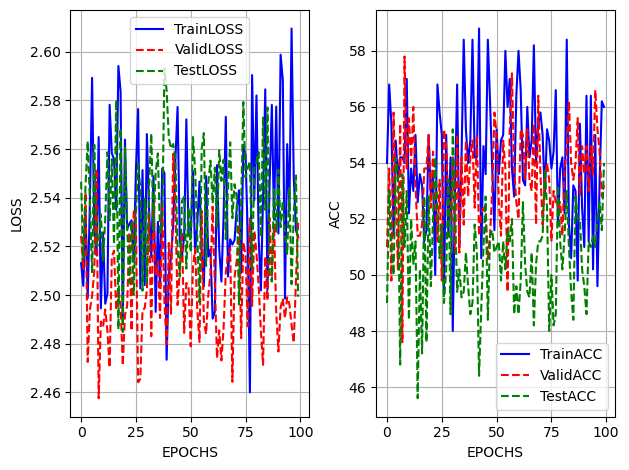

In [76]:

# MODEL.eval()
# xdata = range(self.EPOCH)


fig, ax = plt.subplots(1,2)
ax = ax.flatten()
ax[0].plot(trainDF['loss'], 'b-', label='TrainLOSS')
ax[1].plot(trainDF['acc'], 'b-', label='TrainACC')

ax[0].plot(validDF['loss'], 'r--', label='ValidLOSS')
ax[1].plot(validDF['acc'], 'r--', label='ValidACC')

ax[0].plot(testDF['loss'], 'g--', label='TestLOSS')
ax[1].plot(testDF['acc'], 'g--', label='TestACC')


ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('EPOCHS')
ax[1].set_xlabel('EPOCHS')

ax[0].set_ylabel('LOSS')
ax[1].set_ylabel('ACC')
plt.tight_layout()
plt.show()